 # Titanic EDA — базовий аналіз

  **Мета:** зрозуміти структуру датасету, знайти пропуски, побудувати перші гіпотези.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 1. Огляд датасету
Розмір, типи колонок, скільки пасажирів у датасеті.

In [2]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


## 2. Пропуски у даних 
Які колонки чисті, які треба буде обробляти перед моделюванням.

In [3]:
titanic.isna().sum().sort_values(ascending=False)

deck           688
age            177
embarked         2
embark_town      2
survived         0
pclass           0
sex              0
sibsp            0
parch            0
fare             0
class            0
who              0
adult_male       0
alive            0
alone            0
dtype: int64

## 3. Загальна частка тих, хто вижив
Baseline для будь-якої моделі: якщо просто прогнозувати "всі загинули" - яка буде точність?

In [4]:
titanic["survived"].mean()

np.float64(0.3838383838383838)

## 4. Виживання за статтю
**Гіпотеза:** "women and children first" повинна показувати помітну різницю.

In [5]:
titanic.groupby("sex")["survived"].mean()

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

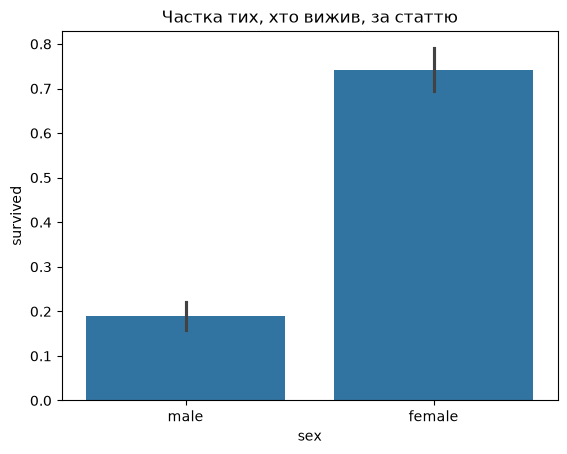

In [6]:
sns.barplot(data=titanic, x="sex", y="survived");
plt.title("Частка тих, хто вижив, за статтю");

## 5. Виживання по класах

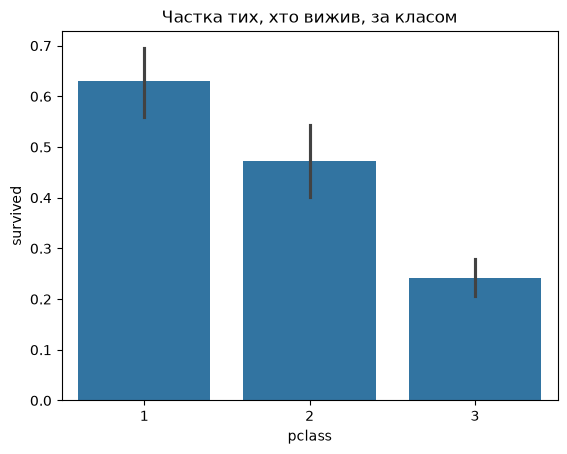

In [7]:
sns.barplot(data=titanic, x="pclass", y="survived");
plt.title("Частка тих, хто вижив, за класом");

## 6. Комбінований зріз: стать * клас

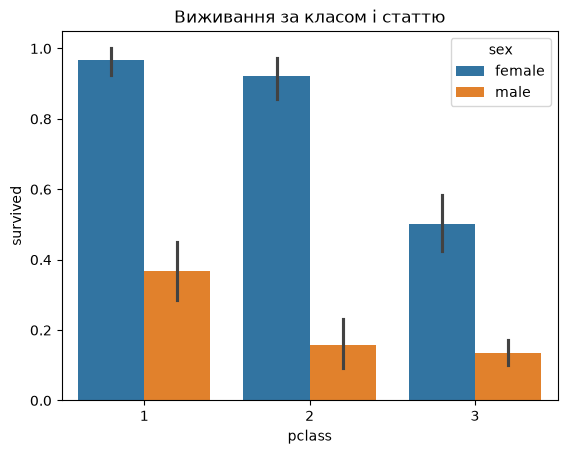

In [8]:
sns.barplot(data=titanic, x="pclass", y="survived", hue="sex");
plt.title("Виживання за класом і статтю");

## 7. Кореляційна матриця числових фіч
Швидкий скринінг: що з чим корелює. Шукаємо |r| > 0.7 як прапорець мультиколінеарності.

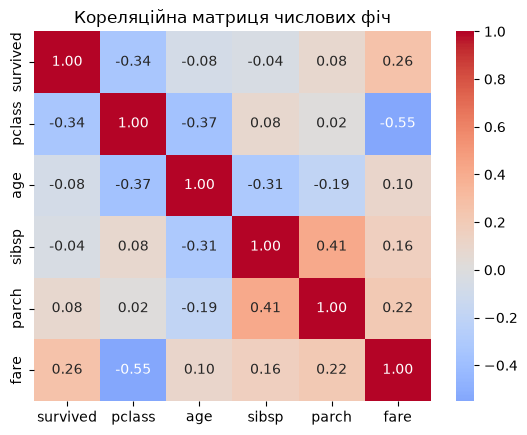

In [9]:
numeric = titanic.select_dtypes(include="number")
corr = numeric.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f");
plt.title("Кореляційна матриця числових фіч");

## 8. Висновоки

 - ~38% пасажирів вижили — baseline модель "всі загинули" мала б 62% accuracy.
 - Стать — найсильніший single predictor (female 74% vs male 19%).
 - Клас — сильний градієнт (1-й 63% → 3-й 24%).
 - pclass ↔ fare = -0.55 — сильна мультиколінеарність (proxy для класу).
 - `deck` 77% NaN — треба або викинути, або отримати з `cabin`.